Checking for required files...
✓ Found ../samples/suno_samples/audio/2cf8e9fb-f670-4223-89a8-d6bbb83887fd.mp3
✓ Found ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/bass.mid
✓ Found ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/harmony.mid

All files found! Ready to proceed with analysis.

=== Step 1: Extracting Beat Timings with -20ms Shift ===
Extracting beats from ../samples/suno_samples/audio/2cf8e9fb-f670-4223-89a8-d6bbb83887fd.mp3 with 20ms shift
Tempo estimate: 123.05 BPM, extracted 242 beats
Extracted 242 beats at tempo 123.05 BPM

Listen to audio with beat clicks to verify alignment:



=== Step 2: Loading and Preparing MIDI Notes ===
Loading MIDI file: ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/bass.mid
Extracted 606 notes from ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/bass.mid
Loading MIDI file: ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/harmony.mid
Extracted 1489 notes from ../samples/suno_samples/segmented/2cf8e9fb-f670-4223-89a8-d6bbb83887fd/midi/harmony.mid
Original bass notes: 606
Cleaned bass notes: 192
Removed 414 parallel bass notes
Original total duration: 304.17 beats
Cleaned total duration: 186.42 beats
Original time span: 0.67 to 238.50
Cleaned time span: 0.67 to 238.50
Combined 192 bass notes with 1489 harmony notes

=== Step 3: Extract Chords with 1-Beat Windows ===

=== Step 3: Extract Chords with 1-Beat Windows ===
Merged adjacent identical chords: 163 chords after merging
Analyzed 242 beats
Extracted 163 chords using 1-beat windows
  - 160 bass-confi

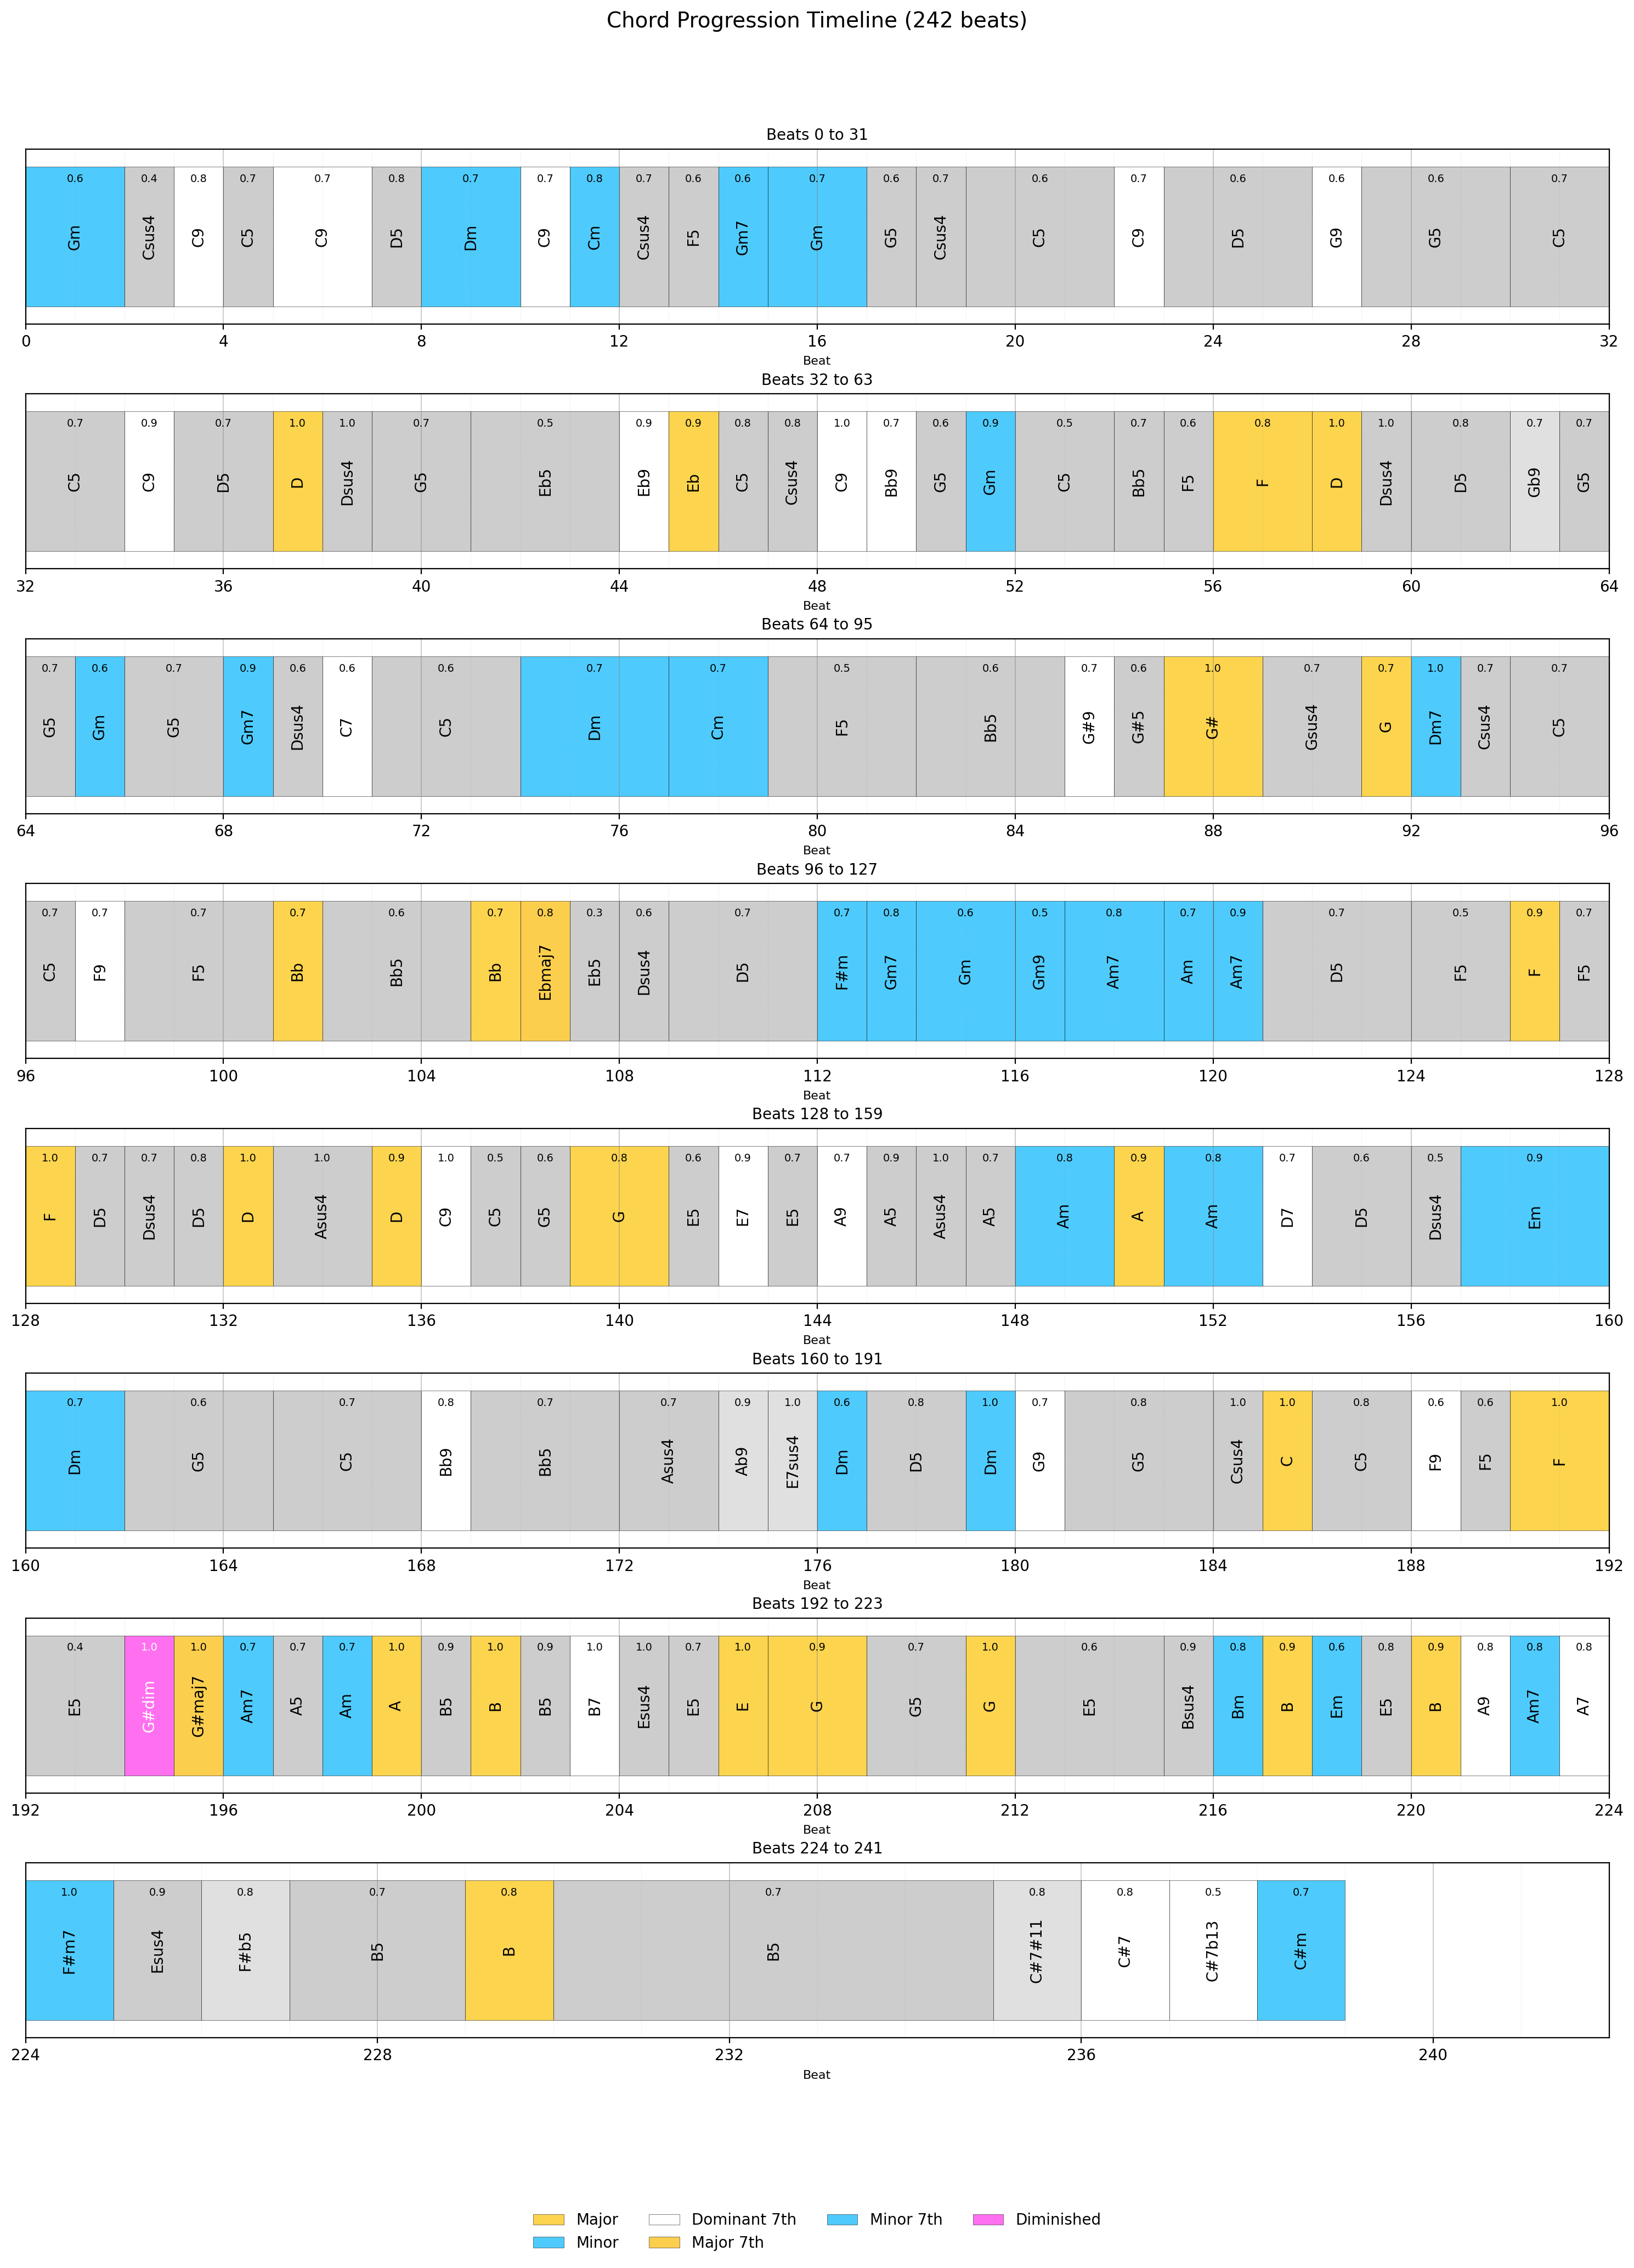

Visualization saved as: chord_progression.pdf

=== Step 4: Extract Chords with 2-Beat Windows ===

=== Step 5: Compare 1-Beat vs 2-Beat Window Results ===

Visualizing first 4 bars with 1-beat window chords:


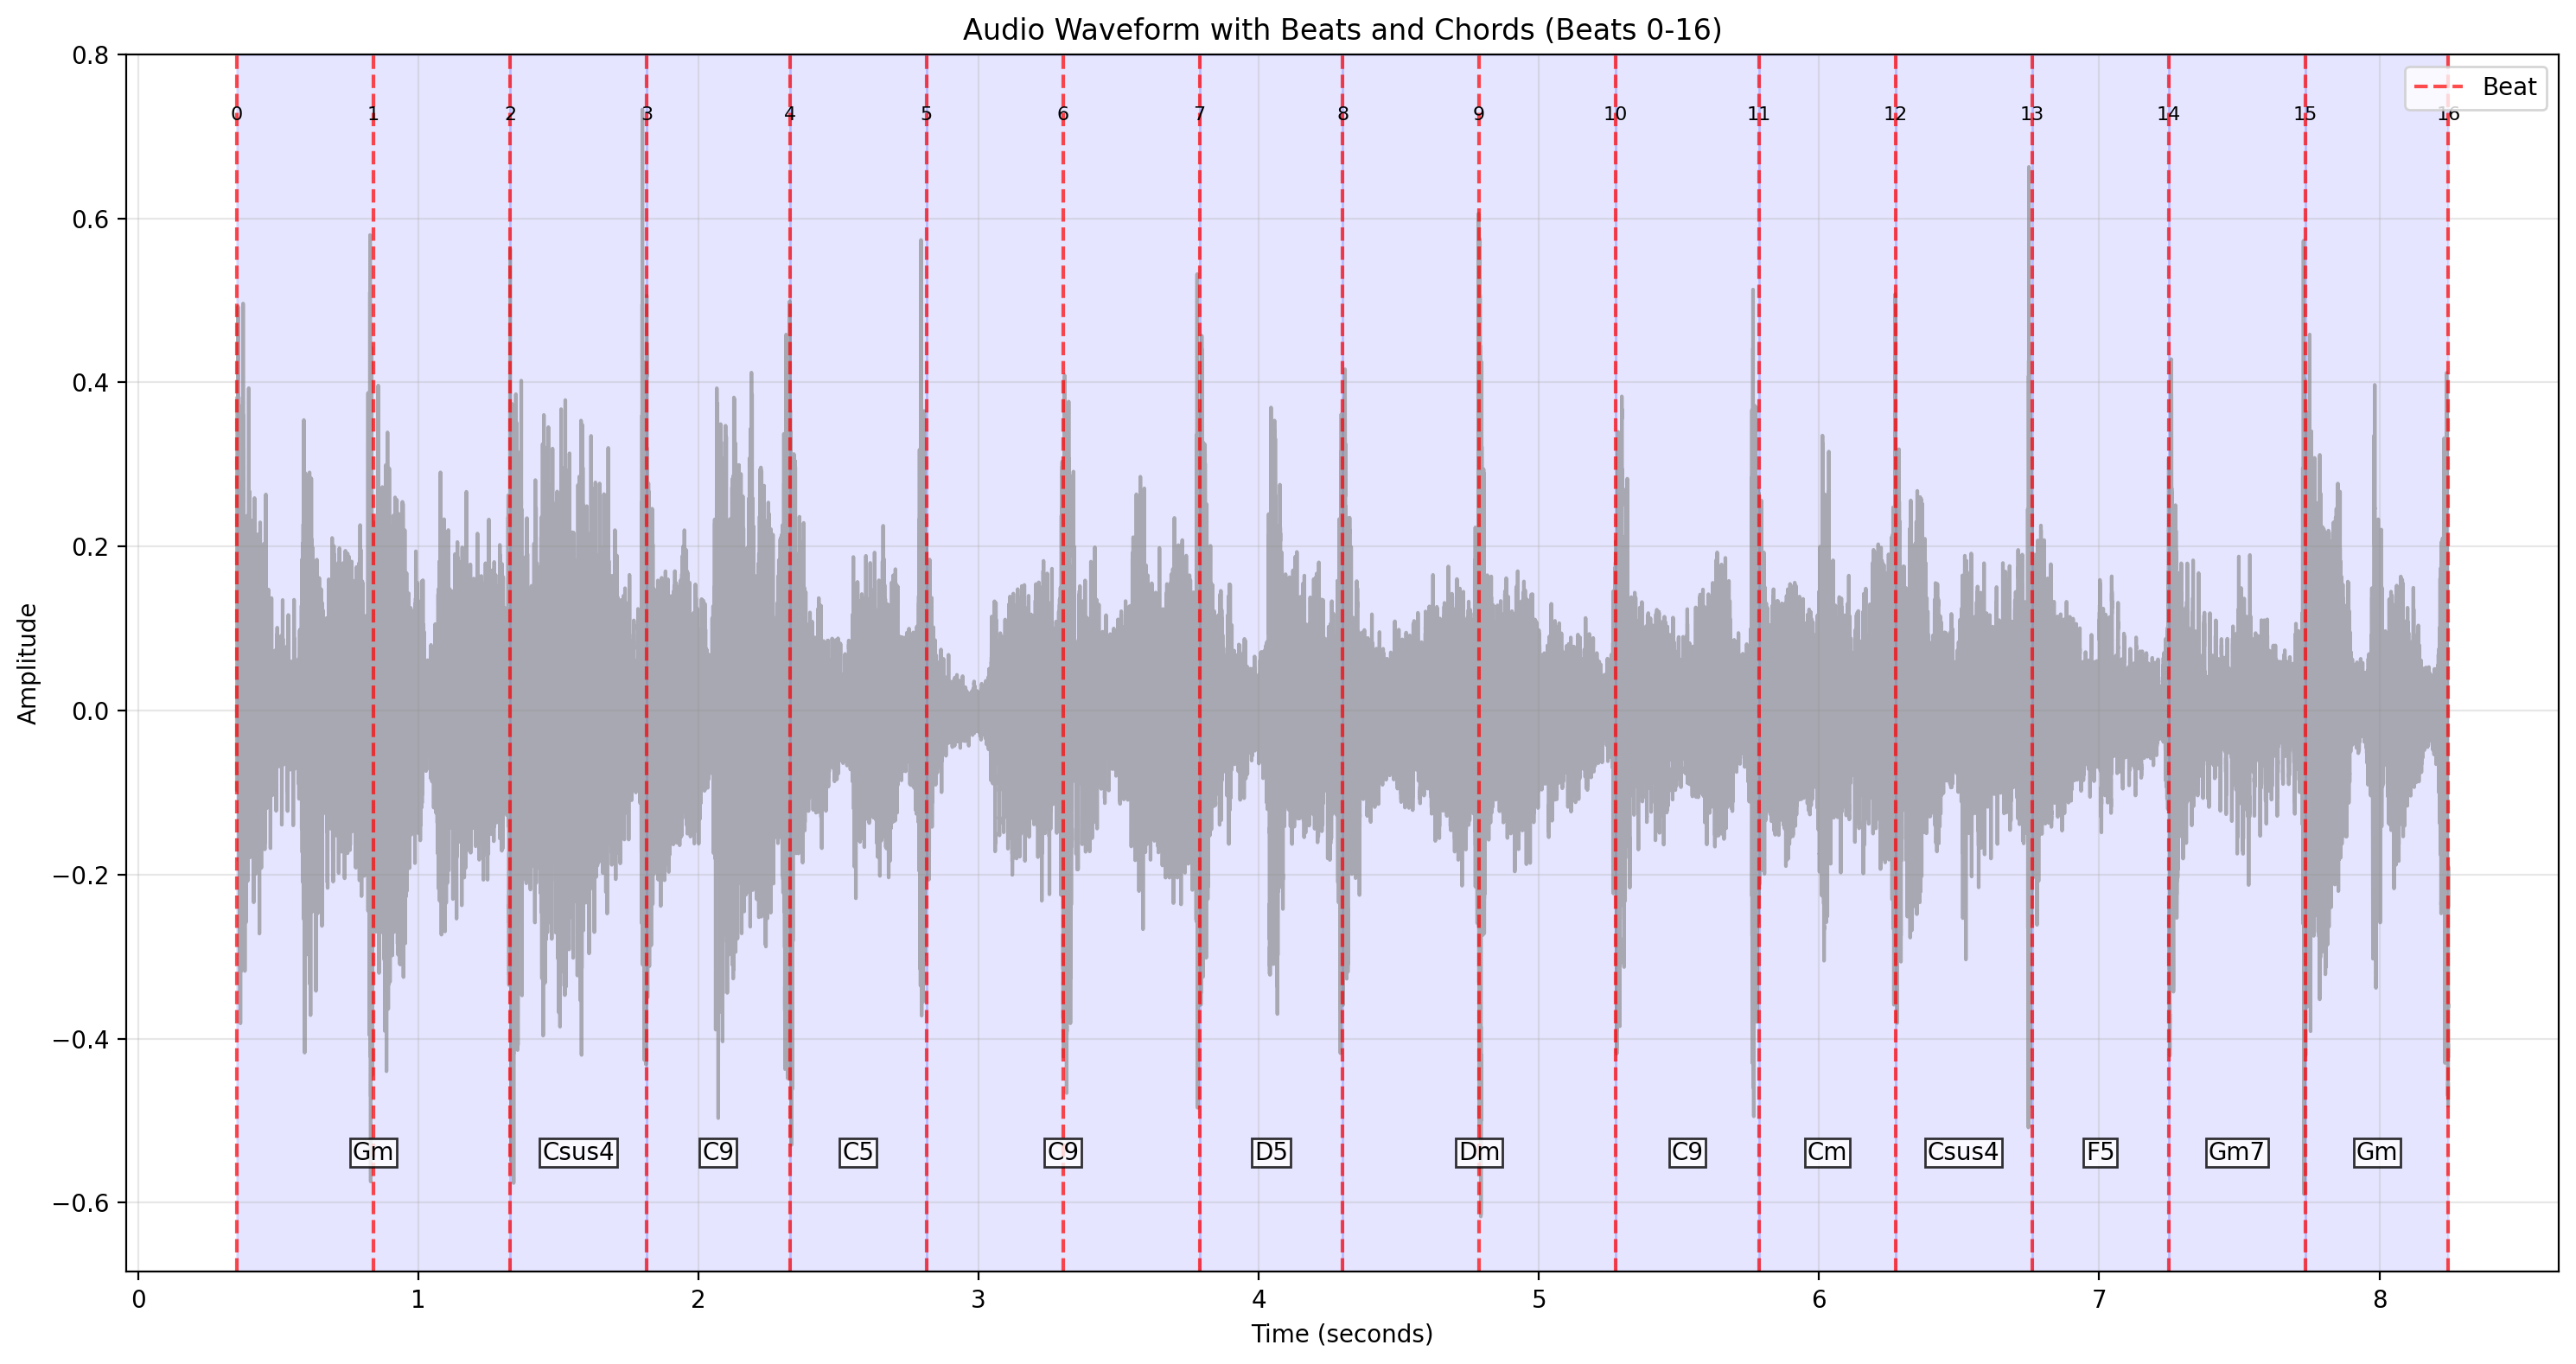


Audio with 1-beat window chord analysis:



Chord Progression Comparison for the first 4 bars:
Beat  1-Beat Window   2-Beat Window  
---------------------------------------------
0     Gm             
1     Gm             
2     Csus4          
3     C9             
4     C5             
5     C9             
6     C9             
7     D5             
8     Dm             
9     Dm             
10    C9             
11    Cm             
12    Csus4          
13    F5             
14    Gm7            
15    Gm             

=== Step 6: Analysis of Chord Stability and Confidence ===
Average chord confidence with 1-beat windows: 0.7564
Chord changes per bar with 1-beat windows: 0.67

Chord agreement analysis:
Chord agreement between 1-beat and 2-beat windows: 0.00%


In [2]:
# Beat-Aligned Chord Analysis Demo

# Import necessary libraries
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import pretty_midi
import os
import sys

# Import our new integrated beat and chord analyzer
from beats_and_chords import (
    extract_beats_with_shift,
    extract_chords_with_beat_windows,
    visualize_beats_and_chords,
    compare_window_sizes,
    analyze_song_chords
)

# Import required functions from chordAnalyzer
from chordAnalyzer import (
    load_midi_notes, 
    clean_bass_line,
    plot_chord_timeline_multirow
)

# Define paths for the example song
song_id = "2cf8e9fb-f670-4223-89a8-d6bbb83887fd"
base_path = "../samples/suno_samples"
audio_path = f"{base_path}/audio/{song_id}.mp3"
midi_base_path = f"{base_path}/segmented/{song_id}/midi"
bass_midi_path = f"{midi_base_path}/bass.mid"
harmony_midi_path = f"{midi_base_path}/harmony.mid"

# Check if files exist
print("Checking for required files...")
all_files_exist = True

for file_path in [audio_path, bass_midi_path, harmony_midi_path]:
    if os.path.exists(file_path):
        print(f"✓ Found {file_path}")
    else:
        print(f"✗ Missing {file_path}")
        all_files_exist = False

if not all_files_exist:
    print("\nError: Some required files are missing. Please check paths.")
    sys.exit(1)

print("\nAll files found! Ready to proceed with analysis.")

# Step 1: Extract beats with -20ms shift for better alignment
print("\n=== Step 1: Extracting Beat Timings with -20ms Shift ===")
ms_shift = 20  # 20 milliseconds shift as seen in the original code
y, sr, beats_shifted, tempo = extract_beats_with_shift(audio_path, ms_shift)

# Create audio with beat clicks for verification - FIXED VERSION
click_track = librosa.clicks(
    times=beats_shifted, 
    sr=sr, 
    click_freq=660, 
    click_duration=0.1,
    length=len(y)  # Specify length to match audio
)
audio_with_clicks = y + click_track * 0.5

print(f"Extracted {len(beats_shifted)} beats at tempo {tempo:.2f} BPM")
print("\nListen to audio with beat clicks to verify alignment:")
display(Audio(data=audio_with_clicks, rate=sr))

# Step 2: Load and prepare MIDI notes
print("\n=== Step 2: Loading and Preparing MIDI Notes ===")
bass_notes = load_midi_notes(bass_midi_path, source_name='bass')
harmony_notes = load_midi_notes(harmony_midi_path, source_name='harmony')

# Clean the bass line to ensure it's monophonic
cleaned_bass = clean_bass_line(bass_notes)

# Combine cleaned bass with harmony notes
combined_notes = cleaned_bass + harmony_notes
combined_notes.sort(key=lambda x: x['start'])

print(f"Combined {len(cleaned_bass)} bass notes with {len(harmony_notes)} harmony notes")

# Step 3: Extract chords using 1-beat windows
print("\n=== Step 3: Extract Chords with 1-Beat Windows ===")
# Extract chords

# Step 3: Extract chords using 1-beat windows
print("\n=== Step 3: Extract Chords with 1-Beat Windows ===")
# Extract chords using 1-beat windows
chords_1beat = extract_chords_with_beat_windows(
    combined_notes, beats_shifted, window_size=1, merge=True, verbose=True, use_bars=False
)

# Calculate the beats
total_beats = len(beats_shifted)
# Use 32 beats per row (equivalent to your previous 8 bars per row with 4 beats per bar)
beats_per_row = 32


# Visualize 1-beat window results
print("\nChord progression with 1-beat windows:")
plot_chord_timeline_multirow(chords_1beat, total_beats, beats_per_row=beats_per_row)

# Step 4: Extract chords using 2-beat windows
print("\n=== Step 4: Extract Chords with 2-Beat Windows ===")


# Step 5: Compare 1-beat vs 2-beat window results
print("\n=== Step 5: Compare 1-Beat vs 2-Beat Window Results ===")
# Choose a section to visualize (first 4 bars)
start_bar = 0
num_bars = 4
start_beat = start_bar * 4  # Assuming 4/4 time
num_beats = 16

# Visualize audio with beats and chords for both window sizes
print("\nVisualizing first 4 bars with 1-beat window chords:")
audio_1beat = visualize_beats_and_chords(
    audio_path, beats_shifted, chords_1beat, start_beat, num_beats
)

print("\nAudio with 1-beat window chord analysis:")
display(audio_1beat)

# Print chord progression comparison for the visualized section
print("\nChord Progression Comparison for the first 4 bars:")
print(f"{'Beat':<5} {'1-Beat Window':<15} {'2-Beat Window':<15}")
print("-" * 45)

for beat in range(start_beat, start_beat + num_beats):
    
    # Find chords at this beat
    chord_1beat = next((c['chord_name'] for c in chords_1beat 
                      if c['beat_start'] <= beat and c['beat_end'] > beat), "-")
    
    print(f"{beat:<5} {chord_1beat:<15}")

# Step 6: Analysis of chord stability and confidence
print("\n=== Step 6: Analysis of Chord Stability and Confidence ===")

# Compare average confidence between 1-beat and 2-beat windows
avg_confidence_1beat = np.mean([c['confidence'] for c in chords_1beat])

print(f"Average chord confidence with 1-beat windows: {avg_confidence_1beat:.4f}")

# Calculate chord changes per bar
chord_changes_1beat = sum(1 for i in range(1, len(chords_1beat)) 
                        if chords_1beat[i]['chord_name'] != chords_1beat[i-1]['chord_name'])

bars_with_chords = len(beats_shifted)
print(f"Chord changes per bar with 1-beat windows: {chord_changes_1beat / max(1, bars_with_chords):.2f}")

# Analyze chord agreement between methods
print("\nChord agreement analysis:")
matching_beats = 0
total_compared_beats = 0

for beat in range(len(beats_shifted) - 1):
    # Find chords at this beat for both methods
    chord_1beat = next((c['chord_name'] for c in chords_1beat 
                      if c['beat_start'] <= beat and c['beat_end'] > beat), None)
    

agreement_percentage = (matching_beats / max(1, total_compared_beats)) * 100
print(f"Chord agreement between 1-beat and 2-beat windows: {agreement_percentage:.2f}%")
